The objective of this notebook is to illustrate how the classification models can be used 

Let's first import the modules we need:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pickle as pkl

We now need to load our data and the classification model. Here, we will be using the RBF kernel SVM inclusive of PAHs, but the process is the same for the others.

In [2]:
data_path = 'demo_data.csv'
data_df = pd.read_csv(data_path)
data_df.fillna(0,inplace=True)
data_df = data_df[data_df['Molecular Formula']!=0]

In [3]:
model_path = '..\\vk_definitions\\models\\svm_rbf_with_pahs.pkl'
with open(model_path, "rb") as f:
    model= pkl.load(f)

Once we load our data, in this specific case we may notice that the formula assignment programme did not include a N/C column. This is easily fixed through pandas.

In [4]:
print(data_df.columns)

Index(['Index', 'm/z', 'Calibrated m/z', 'Calculated m/z', 'Peak Height',
       'Resolving Power', 'S/N', 'Ion Charge', 'm/z Error (ppm)',
       'm/z Error Score', 'Isotopologue Similarity', 'Confidence Score', 'DBE',
       'H/C', 'O/C', 'Heteroatom Class', 'Ion Type', 'Is Isotopologue',
       'Mono Isotopic Index', 'Molecular Formula', 'C', 'H', 'O', 'S', 'N',
       '13C', '34S', '18O'],
      dtype='object')


In [5]:
ratios_needed = ['O/C','H/C','N/C']

for ratio in ratios_needed:
    
    if ratio not in data_df.columns:
        
        elements = ratio.split('/')

        denominator = data_df[elements[1]]

        if elements[1] == 'C':
            denominator += data_df['13C']
        
        data_df[ratio] = data_df[elements[0]] / denominator

Now everything is ready for the classification model to predict compound classes!

In [6]:
predictions = model.predict(data_df[['O/C','H/C','N/C']].values)
predictions

array(['pah', 'lignin', 'lipid', ..., 'tannin', 'lignin', 'carbohydrate'],
      shape=(1954,), dtype=object)

The function ```predict_proba``` finds the predicted probability for each class.

In [7]:
predictions_probabilities = model.predict_proba(data_df[['O/C','H/C','N/C']].values)
predictions_probabilities

array([[2.37081017e-05, 7.89698004e-05, 1.18608459e-04, ...,
        9.22216246e-01, 5.14971497e-05, 6.95580336e-02],
       [1.02997117e-04, 3.78665003e-03, 9.10139047e-01, ...,
        7.35610770e-05, 9.14566430e-04, 5.32751409e-04],
       [3.30711449e-02, 1.60597999e-01, 2.20209952e-04, ...,
        6.86985622e-05, 6.75240168e-05, 8.00546848e-06],
       ...,
       [8.16310079e-04, 9.48058386e-05, 1.98024168e-01, ...,
        2.72614490e-04, 1.81432174e-04, 7.96273520e-01],
       [4.06274369e-05, 1.56238570e-04, 8.62209193e-01, ...,
        2.89579074e-04, 9.38582721e-05, 1.32916389e-01],
       [9.09653635e-02, 6.35515038e-01, 2.26974109e-03, ...,
        7.17878424e-05, 7.38320050e-05, 1.10963853e-05]], shape=(1954, 7))

The probability of the assigned class can thus be found. Both the assignments and their probabilities can then be added as columns in the dataframe.

In [8]:
max_probabilities = np.max(predictions_probabilities,axis=1)

data_df['assignment'] = predictions
data_df['probability'] = max_probabilities
data_df

,Index,m/z,Calibrated m/z,Calculated m/z,Peak Height,Resolving Power,S/N,Ion Charge,m/z Error (ppm),m/z Error Score,...,H,O,S,N,13C,34S,18O,N/C,assignment,probability
0,0,645.219141,645.218553,645.218366,5589082.620,3.194603e+05,9.919174,-1,0.288938,0.628885,...,30.0,3.0,0.0,2.0,0.0,0.0,0.0,0.044444,pah,0.922216
1,1,619.203677,619.203125,619.203229,6113076.916,3.328825e+05,10.849129,-1,-0.168585,0.853940,...,36.0,14.0,0.0,0.0,0.0,0.0,0.0,0.000000,lignin,0.910139
2,2,617.358234,617.357685,617.357622,6211083.724,3.338773e+05,11.023065,-1,0.101289,0.944597,...,58.0,12.0,1.0,0.0,0.0,0.0,0.0,0.000000,lipid,0.805966
3,3,613.541768,613.541223,613.541264,7968661.525,2.687634e+05,14.142311,-1,-0.065776,0.976251,...,74.0,6.0,0.0,0.0,0.0,0.0,0.0,0.000000,lipid,0.904822
4,4,607.239979,607.239443,607.239615,7298141.809,3.394405e+05,12.952312,-1,-0.282904,0.641057,...,40.0,13.0,0.0,0.0,0.0,0.0,0.0,0.000000,lignin,0.905843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1949,2351,213.076904,213.076827,213.076847,5749930.499,9.673598e+05,10.204638,-1,-0.093090,0.952997,...,14.0,5.0,0.0,0.0,0.0,0.0,0.0,0.000000,lignin,0.894216
1950,2352,211.061284,211.061210,211.061197,5424363.499,7.812782e+05,9.626841,-1,0.062067,0.978826,...,12.0,5.0,0.0,0.0,0.0,0.0,0.0,0.000000,lignin,0.909204
1951,2353,211.024872,211.024798,211.024811,8186239.603,7.814130e+05,14.528456,-1,-0.065141,0.976702,...,8.0,6.0,0.0,0.0,0.0,0.0,0.0,0.000000,tannin,0.796274
1952,2354,209.045597,209.045525,209.045547,7740860.279,9.860143e+05,13.738023,-1,-0.105687,0.939832,...,10.0,5.0,0.0,0.0,0.0,0.0,0.0,0.000000,lignin,0.862209


The results can be plotted on a 2D van Kreveln diagram.

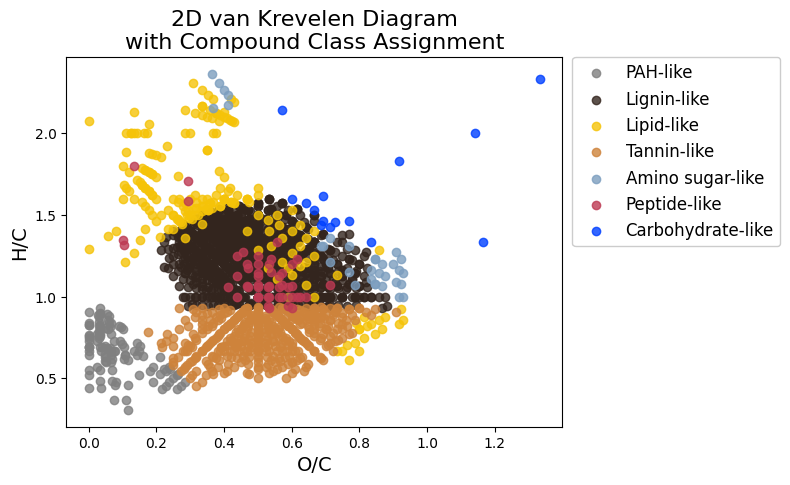

In [9]:
vk_region_colours = {
    'lipid': '#F5C308',
    'peptide': '#BD3A53',
    'carbohydrate': '#0040FF',
    'amino_sugar': '#7C9EBF',
    'lignin': '#33251E',
    'tannin': '#CE833B',
    'pah': "#808080",
}

fig, ax = plt.subplots()

for compound_class in data_df['assignment'].unique():

    ax.scatter(data_df[data_df['assignment']==compound_class]['O/C'],
               data_df[data_df['assignment']==compound_class]['H/C'],
               c=vk_region_colours[compound_class],
               label=f'{compound_class.replace('_',' ').capitalize()}-like' if 'pah' not in compound_class else 'PAH-like',
               alpha=0.8)

ax.set_xlabel('O/C',fontsize=14)
ax.set_ylabel('H/C',fontsize=14)
ax.set_title('2D van Krevelen Diagram\nwith Compound Class Assignment',fontsize=16)
ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
fig.savefig('2d_vK.png', dpi=600, facecolor='#fff', bbox_inches='tight')

Alternatively, the Plotly package can be used to draw 3D diagrams with N/C as an additional axis.

In [10]:
vizList = []
for compound_class in data_df['assignment'].unique():

    globals()[f"D_{compound_class}"]=go.Scatter3d(

        x = data_df[data_df['assignment'] == compound_class]['O/C'],
        y = data_df[data_df['assignment'] == compound_class]['H/C'],
        z = data_df[data_df['assignment'] == compound_class]['N/C'],

        name = f'{compound_class.replace('_',' ').capitalize()}-like' if 'pah' not in compound_class else 'PAH-like',

        hovertemplate = 'O/C: %{x} <br>' + \
                        'H/C: %{y} <br>' + \
                        'N/C: %{z} <br>',

        mode='markers',
        marker=dict(
            size=8,
            color=vk_region_colours[compound_class],           
            opacity=0.8,
            symbol='circle'
        )
    )

    vizList.append(globals()[f"D_{compound_class}"]) 

fig = go.Figure(data=vizList)

camera = dict(
        up=dict(x=0, y=0, z=1),
        center=dict(x=0, y=0, z=0),
        eye=dict(x=-1, y=-1.75, z=1.5)
    )

fig.update_layout(
    scene_camera=camera,
    autosize=True,
    template="plotly_white",
    scene={
        "xaxis_title":'O/C',
        "yaxis_title":'H/C',
        "zaxis_title":'N/C'
    },
    width=800, height=600,
    showlegend=True,
    legend_font_size = 14,
    title = '3D van Krevelen Diagram with Compound Class Assignment',
    title_font_size = 20
)

fig.show()

# 3D vK diagrams created with Plotly are saved as HTML files
fig.write_html('3d_vK.html')

Finally, we can save the dataframe to a new CSV file with the assignment data.

In [11]:
data_df.to_csv('demo_data--assigned.csv',index=None)